In [1]:
import pandas as pd
from pathlib import Path

base = Path("grasp_6dof/out")
dfs = []
for name in ["cylinder_0p08", "sphere_small_0p08"]:
    df = pd.read_csv(base / f"{name}_lggsn.csv")
    df["obj_name"] = name
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
df_all.head()


,x,y,z,roll,pitch,yaw,width,score,success,obj_name
0,0.382441,-0.033615,0.054224,-3.077228,0.037145,1.570203,0.08,0.930392,1,cylinder_0p08
1,0.380748,-0.037007,0.054528,-3.123575,0.013576,-3.141482,0.08,0.930222,1,cylinder_0p08
2,0.374378,-0.033432,0.053814,3.132359,-0.085878,-0.009433,0.08,0.929278,0,cylinder_0p08
3,0.378302,0.048991,0.054318,-3.092045,-0.008453,-1.568283,0.08,0.927770,0,cylinder_0p08
4,0.373497,-0.006796,0.094165,-0.018027,0.019567,3.140274,0.08,0.927596,0,cylinder_0p08


In [2]:
# 每个物体的样本数和 success 率
df_all.groupby("obj_name")["success"].agg(["count", "mean"])
# score 分布
df_all.groupby("obj_name")["score"].describe()


,count,mean,std,min,25%,50%,75%,max
obj_name,,,,,,,,
cylinder_0p08,64.0,0.909798,0.009732,0.896442,0.902866,0.907438,0.914962,0.930392
sphere_small_0p08,12.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Stage 2: 6-DoF Grasp Dataset Overview

In this stage, we build a simulated 6-DoF grasp dataset on simple geometric objects, which will be used as supervised data for the later **Language-Guided Grasp Scoring Network (LG-GSN)**.

### Data generation pipeline

For each object mesh (e.g., cylinder, small sphere), we run the following pipeline:

1. **Geometric grasp sampling**  
   - Input: watertight mesh in object frame.  
   - Output: a set of candidate 6-DoF grasp poses:
     \[
     (x, y, z, \mathrm{roll}, \mathrm{pitch}, \mathrm{yaw}, \text{width}, \text{score})
     \]
   - Saved to:  
     `grasp_6dof/dataset/<obj>_grasps.json`

2. **Physics-based validation (PyBullet)**  
   - The object is placed on a table in PyBullet with a Panda-like gripper.  
   - Each candidate grasp is executed in open-loop:
     - Move to pre-grasp pose
     - Descend along approach direction
     - Close gripper
     - Lift and check object stability
   - Saved to:  
     `grasp_6dof/out/<obj>_grasps_validated.json`

3. **LG-GSN ready format**  
   - All validated grasps are converted to a unified tabular format for learning:
     - JSON: `grasp_6dof/out/<obj>_lggsn.json`  
     - CSV:  `grasp_6dof/out/<obj>_lggsn.csv`

This gives us a clean 6-DoF grasp dataset with explicit success labels, decoupled from language for now, but compatible with later multi-modal conditioning.

---

### Object set (current version)

At the current stage, we include simple, well-controlled shapes:

- `cylinder_0p08`: vertical cylinder with approximate diameter / height 0.08 m  
- `sphere_small_0p08`: small sphere with diameter ≈ 0.08 m  

More shapes (e.g., box, mug-like shapes) can be added later by reusing the same pipeline.


### LG-GSN data schema

All 6-DoF grasps used for LG-GSN training are stored in `*_lggsn.csv` with the following columns:

| Field   | Type    | Description                                                |
|--------|---------|------------------------------------------------------------|
| `x`    | float   | Grasp contact point position (x) in robot base frame (m)  |
| `y`    | float   | Grasp contact point position (y) in robot base frame (m)  |
| `z`    | float   | Grasp contact point position (z) in robot base frame (m)  |
| `roll` | float   | Roll angle of the gripper pose (rad)                       |
| `pitch`| float   | Pitch angle of the gripper pose (rad)                      |
| `yaw`  | float   | Yaw angle of the gripper pose (rad)                        |
| `width`| float   | Gripper opening width at grasp time (m)                    |
| `score`| float   | Geometric grasp quality score (higher is better)           |
| `success` | int  | Execution result in PyBullet (1 = success, 0 = failure)    |

> Note: the orientation convention (`roll`, `pitch`, `yaw`) follows the same order as used in the grasp generator and validation scripts. This should be kept consistent with the control code during execution.

Example (first few rows):

```text
x,y,z,roll,pitch,yaw,width,score,success
0.3824,-0.0336,0.0542,-3.0772,0.0371,1.5702,0.0380,0.9304,1
...


In [4]:
## 放一个 code cell，用来自动扫所有 `*_lggsn.csv`：
import pandas as pd
from pathlib import Path

base = Path("grasp_6dof/out")

csv_files = sorted(base.glob("*_lggsn.csv"))
print("Found CSV files:")
for f in csv_files:
    print(" -", f.name)

rows = []
for f in csv_files:
    df = pd.read_csv(f)
    if "success" not in df.columns:
        print("[WARN] no 'success' column in", f)
        continue
    
    obj_name = f.name.replace("_lggsn.csv", "")
    n_total = len(df)
    n_success = int(df["success"].sum())
    success_rate = n_success / n_total if n_total > 0 else 0.0
    
    rows.append({
        "obj_name": obj_name,
        "N_total": n_total,
        "N_success": n_success,
        "success_rate": success_rate,
    })

summary_df = pd.DataFrame(rows)
summary_df


Found CSV files:
 - cylinder_0p08_lggsn.csv
 - sphere_small_0p08_lggsn.csv


,obj_name,N_total,N_success,success_rate
0,cylinder_0p08,64,37,0.578125
1,sphere_small_0p08,12,10,0.833333


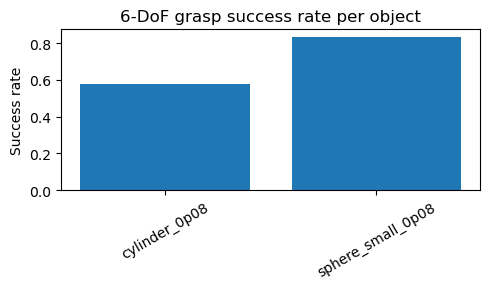

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
plt.bar(summary_df["obj_name"], summary_df["success_rate"])
plt.ylabel("Success rate")
plt.xticks(rotation=30)
plt.title("6-DoF grasp success rate per object")
plt.tight_layout()
plt.show()


cylinder_0p08: 64 grasps


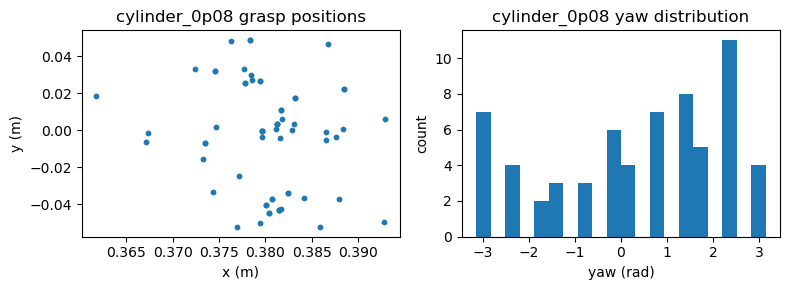

In [6]:
obj = "cylinder_0p08"  # or "sphere_small_0p08"
csv_path = base / f"{obj}_lggsn.csv"

df = pd.read_csv(csv_path)
print(f"{obj}: {len(df)} grasps")

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# (x, y) 平面分布
axes[0].scatter(df["x"], df["y"], s=10)
axes[0].set_xlabel("x (m)")
axes[0].set_ylabel("y (m)")
axes[0].set_title(f"{obj} grasp positions")

# yaw 分布
axes[1].hist(df["yaw"], bins=20)
axes[1].set_xlabel("yaw (rad)")
axes[1].set_ylabel("count")
axes[1].set_title(f"{obj} yaw distribution")

plt.tight_layout()
plt.show()


### Stage 2: Summary of 6-DoF grasp dataset

- We implemented a PyBullet-based 6-DoF grasp data generation pipeline that can be applied to multiple object meshes.
- For each object, we first generate geometric grasp candidates on the mesh surface, and then validate them through physics simulation in a table-top scene.
- All validated grasps are converted into a unified tabular format with fields  
  \[
  (x, y, z, \mathrm{roll}, \mathrm{pitch}, \mathrm{yaw}, \text{width}, \text{score}, \text{success})
  \]
  which will serve as supervised data for the Language-Guided Grasp Scoring Network (LG-GSN).
- In the current version, the dataset contains simple shapes such as `cylinder_0p08` and `sphere_small_0p08`, with per-object grasp success rates summarized in the table above. This provides a clean, controllable benchmark to study how language conditions can modulate grasp selection on top of purely geometric candidates.
